# UMAP + HDBSCAN clustering

In [45]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity


project_directory = Path(
    r"C:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents"
    r"\IMDB_WEEK1_SIX\movie-embeddings-project"
)

movies_df = pd.read_csv(
    project_directory
    / "data"
    / "processed"
    / "movies_cleaned.csv"
).reset_index(drop=True)

genres_df = pd.read_csv(
    project_directory
    / "artifacts"
    / "metadata"
    / "movie_genres.csv"
)

genres_df["genres_set"] = genres_df["genres"].apply(lambda x: set(ast.literal_eval(x)))

gte_embeddings = np.load(
    project_directory
    / "artifacts"
    / "embeddings"
    / "gte_modernbert_embeddings.npy"
).astype(np.float32)

gte_embeddings = normalize(
    gte_embeddings,
    norm="l2",
    axis=1,
)

print(gte_embeddings.shape)

from sklearn.metrics.pairwise import (
    cosine_similarity,
    euclidean_distances,
    manhattan_distances,
)

(9967, 768)


In [46]:
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import umap

umap_reducer = umap.UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

embeddings_umap = umap_reducer.fit_transform(gte_embeddings)

c:\Users\nikola.bakic\OneDrive - Sixsentix AG\Documents\IMDB_WEEK1_SIX\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [47]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="eom",
    max_cluster_size=1200,
)

movies_df["hdbscan_cluster"] = clusterer.fit_predict(embeddings_umap)
movies_df["hdbscan_probability"] = clusterer.probabilities_

cluster_counts = (
    movies_df["hdbscan_cluster"]
    .value_counts()
    .sort_index()
)

number_of_clusters = movies_df.loc[
    movies_df["hdbscan_cluster"] != -1,
    "hdbscan_cluster",
].nunique()

noise_percentage = (
    movies_df["hdbscan_cluster"] == -1
).mean() * 100

print(f"Broj klastera: {number_of_clusters}")
print(f"Noise: {noise_percentage:.2f}%")
display(cluster_counts.to_frame("number_of_movies"))

Broj klastera: 14
Noise: 53.63%


,number_of_movies
hdbscan_cluster,
-1,5345
0,234
1,165
2,754
3,164
4,151
5,397
6,175
7,298


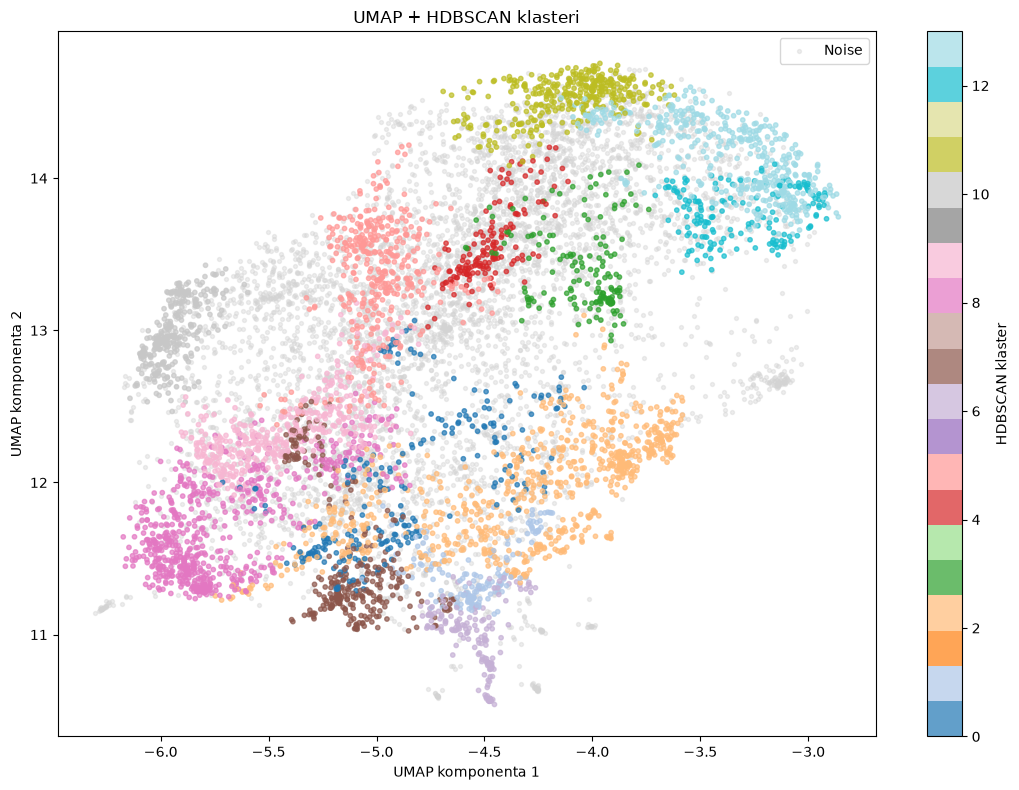

In [48]:
labels = movies_df["hdbscan_cluster"].to_numpy()
noise_mask = labels == -1
cluster_mask = ~noise_mask

plt.figure(figsize=(11, 8))

plt.scatter(
    embeddings_umap[noise_mask, 0],
    embeddings_umap[noise_mask, 1],
    c="lightgray",
    s=8,
    alpha=0.4,
    label="Noise",
)

scatter = plt.scatter(
    embeddings_umap[cluster_mask, 0],
    embeddings_umap[cluster_mask, 1],
    c=labels[cluster_mask],
    cmap="tab20",
    s=10,
    alpha=0.7,
)

plt.colorbar(scatter, label="HDBSCAN klaster")
plt.legend()
plt.xlabel("UMAP komponenta 1")
plt.ylabel("UMAP komponenta 2")
plt.title("UMAP + HDBSCAN klasteri")
plt.tight_layout()
plt.show()

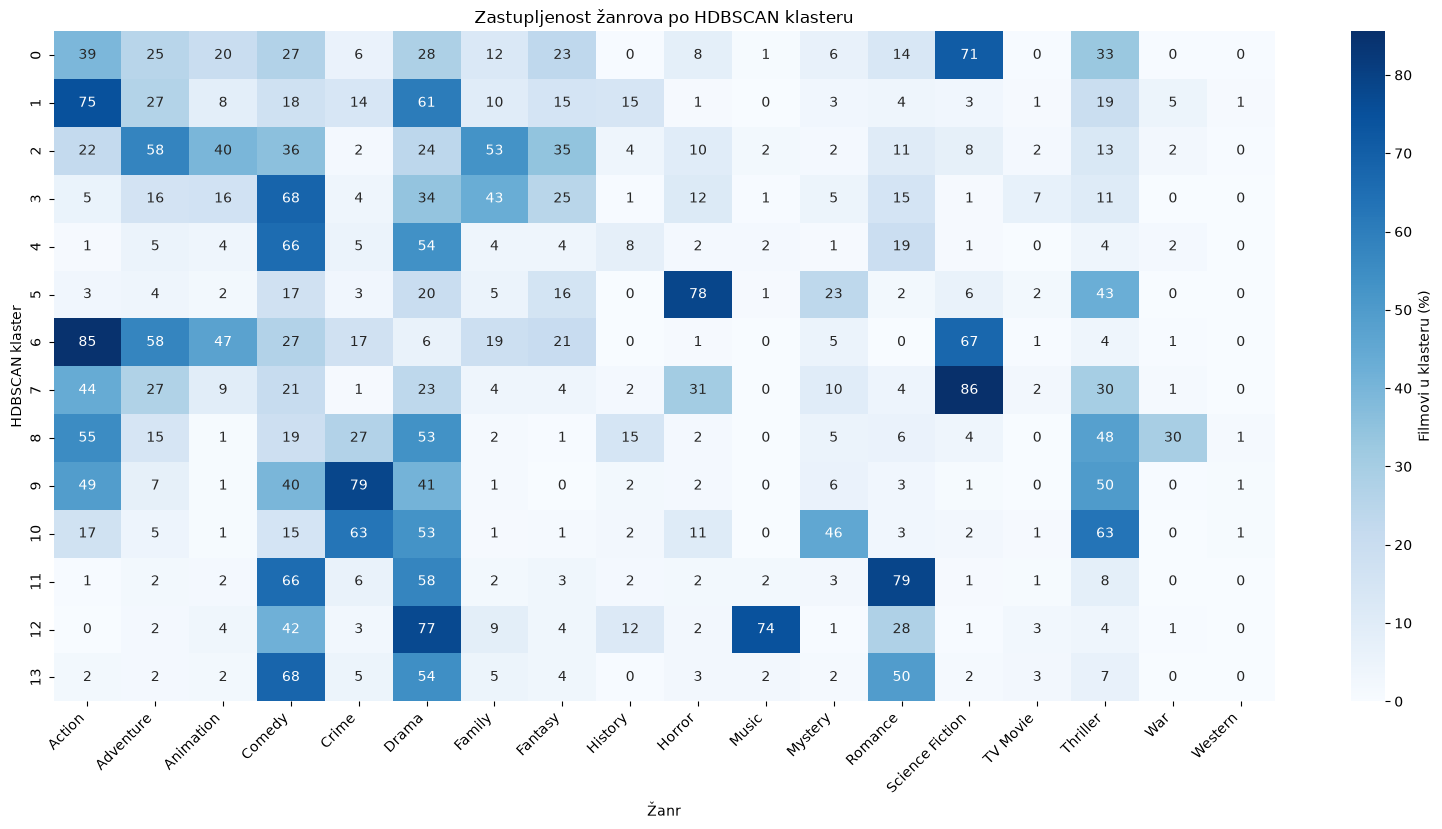

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns


hdbscan_genres_df = movies_df[
    ["movie_id", "title", "hdbscan_cluster"]
].merge(
    genres_df[["movie_id", "genres_set"]],
    on="movie_id",
    how="left",
)

hdbscan_genres_df = hdbscan_genres_df[
    hdbscan_genres_df["hdbscan_cluster"] != -1
]

hdbscan_genres_exploded = (
    hdbscan_genres_df
    .explode("genres_set")
    .dropna(subset=["genres_set"])
)

genre_counts = (
    hdbscan_genres_exploded
    .groupby(["hdbscan_cluster", "genres_set"])
    .size()
)

cluster_sizes = (
    hdbscan_genres_df
    .groupby("hdbscan_cluster")
    .size()
)

genre_percentages = (
    genre_counts
    .div(cluster_sizes, level="hdbscan_cluster")
    .mul(100)
    .unstack(fill_value=0)
)

plt.figure(
    figsize=(16, max(6, len(genre_percentages) * 0.6))
)

sns.heatmap(
    genre_percentages,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Filmovi u klasteru (%)"},
)

plt.xlabel("Žanr")
plt.ylabel("HDBSCAN klaster")
plt.title("Zastupljenost žanrova po HDBSCAN klasteru")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
import numpy as np
import pandas as pd

genre_map = (
    genres_df
    .drop_duplicates("movie_id")
    .set_index("movie_id")["genres"]
)

movies_df["genres"] = movies_df["movie_id"].map(genre_map)

representative_movies = []

cluster_ids = sorted(
    cluster_id
    for cluster_id in movies_df["hdbscan_cluster"].unique()
    if cluster_id != -1
)

for cluster_id in cluster_ids:
    cluster_indices = np.where(
        movies_df["hdbscan_cluster"].to_numpy() == cluster_id
    )[0]

    cluster_embeddings = gte_embeddings[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)

    distances = np.linalg.norm(
        cluster_embeddings - centroid,
        axis=1,
    )

    closest_local_indices = np.argsort(distances)[:5]
    closest_df_indices = cluster_indices[closest_local_indices]

    cluster_movies = movies_df.iloc[closest_df_indices][
        [
            "title",
            "genres",
            "overview",
            "hdbscan_probability",
        ]
    ].copy()

    cluster_movies.insert(0, "cluster", cluster_id)
    cluster_movies.insert(
        1,
        "rank",
        range(1, len(cluster_movies) + 1),
    )
    cluster_movies["centroid_distance"] = distances[
        closest_local_indices
    ]

    representative_movies.append(cluster_movies)

representative_movies_df = pd.concat(
    representative_movies,
    ignore_index=True,
)

representative_movies_df

,cluster,rank,title,genres,overview,hdbscan_probability,centroid_distance
0,0,1,Code 8 Part II,"[""Science Fiction"", ""Action"", ""Crime""]",In a world where superpowered people are heavi...,1.000000,0.548006
1,0,2,Total Recall,"[""Action"", ""Science Fiction"", ""Thriller""]",Factory worker Doug Quaid takes a virtual mind...,0.965514,0.554283
2,0,3,Time Lapse,"[""Thriller"", ""Science Fiction"", ""Mystery"", ""Ho...",Three friends discover a mysterious machine th...,1.000000,0.554360
3,0,4,THX 1138,"[""Science Fiction"", ""Drama""]",People in the future live in a totalitarian so...,1.000000,0.556978
4,0,5,Surrogates,"[""Science Fiction"", ""Action"", ""Thriller""]",Set in a futuristic world where humans live in...,1.000000,0.557234
...,...,...,...,...,...,...,...
65,13,1,Do Revenge,"[""Comedy"", ""Thriller"", ""Romance""]",A dethroned queen bee at a posh private high s...,1.000000,0.512336
66,13,2,Lost and Delirious,"[""Drama"", ""Romance""]","After starting at an upmarket boarding school,...",1.000000,0.518011
67,13,3,Love Hurts,"[""Drama"", ""Romance""]",Family and friends try to sabotage the budding...,1.000000,0.521544
68,13,4,Sierra Burgess Is a Loser,"[""Comedy"", ""Drama"", ""Romance""]",A case of mistaken identity results in unexpec...,1.000000,0.522171


In [53]:
representative_movies_df.to_csv(
    "artifacts/metadata/representative_metadata.csv",
    index=False,
)

In [52]:
from sklearn.preprocessing import normalize


hdbscan_labels = movies_df["hdbscan_cluster"].to_numpy()
cluster_ids = np.array(
    sorted(set(hdbscan_labels) - {-1})
)

centroids = np.vstack(
    [
        gte_embeddings[hdbscan_labels == cluster_id].mean(axis=0)
        for cluster_id in cluster_ids
    ]
)

centroids = normalize(centroids, norm="l2", axis=1)

final_labels = hdbscan_labels.copy()
noise_indices = np.where(hdbscan_labels == -1)[0]

noise_similarities = (
    gte_embeddings[noise_indices] @ centroids.T
)

closest_clusters = cluster_ids[
    noise_similarities.argmax(axis=1)
]

final_labels[noise_indices] = closest_clusters

movies_df["hybrid_cluster"] = final_labels

print(
    movies_df["hybrid_cluster"]
    .value_counts()
    .sort_index()
)

hybrid_cluster
0      518
1      299
2     1262
3      350
4      554
5     1083
6      294
7      431
8     1155
9      908
10     641
11    1131
12     437
13     904
Name: count, dtype: int64


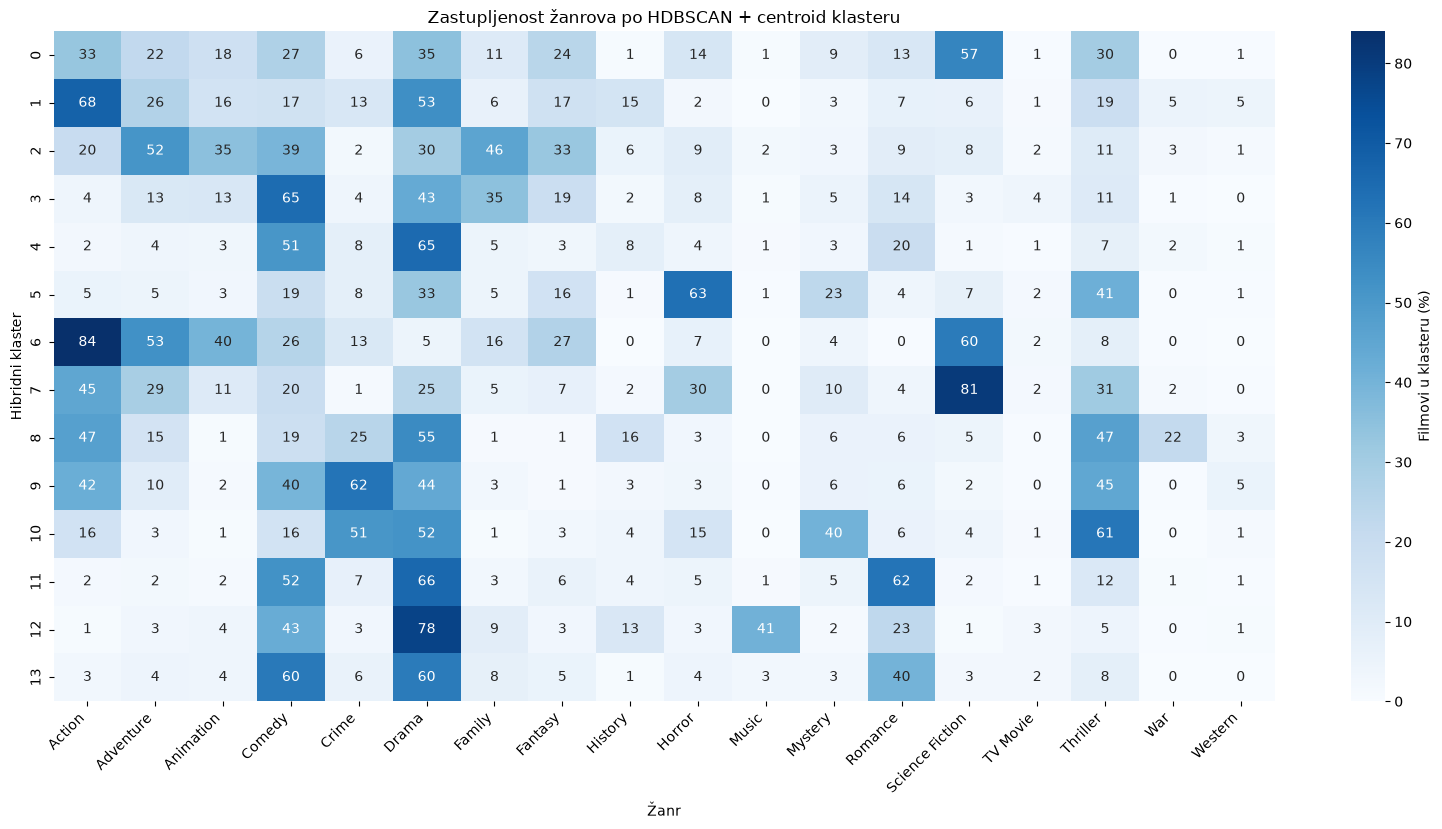

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns


hybrid_genres_df = movies_df[
    ["movie_id", "title", "hybrid_cluster"]
].merge(
    genres_df[["movie_id", "genres_set"]],
    on="movie_id",
    how="left",
)

hybrid_genres_exploded = (
    hybrid_genres_df
    .explode("genres_set")
    .dropna(subset=["genres_set"])
)

genre_counts = (
    hybrid_genres_exploded
    .groupby(["hybrid_cluster", "genres_set"])
    .size()
)

cluster_sizes = (
    hybrid_genres_df
    .groupby("hybrid_cluster")
    .size()
)

genre_percentages = (
    genre_counts
    .div(cluster_sizes, level="hybrid_cluster")
    .mul(100)
    .unstack(fill_value=0)
)

plt.figure(
    figsize=(16, max(6, len(genre_percentages) * 0.6))
)

sns.heatmap(
    genre_percentages,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Filmovi u klasteru (%)"},
)

plt.xlabel("Žanr")
plt.ylabel("Hibridni klaster")
plt.title(
    "Zastupljenost žanrova po HDBSCAN + centroid klasteru"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [55]:
import numpy as np
import pandas as pd


genre_map = (
    genres_df
    .drop_duplicates("movie_id")
    .set_index("movie_id")["genres"]
)

movies_df["genres"] = movies_df["movie_id"].map(genre_map)

representative_hybrid_movies = []

cluster_ids = sorted(
    movies_df["hybrid_cluster"].unique()
)

for cluster_id in cluster_ids:
    cluster_indices = np.where(
        movies_df["hybrid_cluster"].to_numpy() == cluster_id
    )[0]

    cluster_embeddings = gte_embeddings[cluster_indices]

    centroid = cluster_embeddings.mean(axis=0)

    distances = np.linalg.norm(
        cluster_embeddings - centroid,
        axis=1,
    )

    closest_local_indices = np.argsort(distances)[:5]
    closest_df_indices = cluster_indices[
        closest_local_indices
    ]

    cluster_movies = movies_df.iloc[
        closest_df_indices
    ][
        [
            "title",
            "genres",
            "overview",
        ]
    ].copy()

    cluster_movies.insert(
        0,
        "cluster",
        cluster_id,
    )
    cluster_movies.insert(
        1,
        "rank",
        range(1, len(cluster_movies) + 1),
    )
    cluster_movies["centroid_distance"] = distances[
        closest_local_indices
    ]

    representative_hybrid_movies.append(cluster_movies)

representative_hybrid_movies_df = pd.concat(
    representative_hybrid_movies,
    ignore_index=True,
)

representative_hybrid_movies_df

,cluster,rank,title,genres,overview,centroid_distance
0,0,1,Psychokinesis,"[""Fantasy"", ""Action"", ""Comedy""]",An ordinary guy suddenly finds he has superpow...,0.549487
1,0,2,Hello World,"[""Animation"", ""Romance"", ""Science Fiction"", ""D...",A shy high schooler in Kyoto meets a man claim...,0.557144
2,0,3,Black Box,"[""Horror"", ""Science Fiction""]",After losing his wife and his memory in a car ...,0.557429
3,0,4,A-X-L,"[""Science Fiction"", ""Action"", ""Adventure"", ""Fa...",The life of a teenage boy is forever altered b...,0.558370
4,0,5,Total Recall,"[""Action"", ""Science Fiction"", ""Thriller""]",Factory worker Doug Quaid takes a virtual mind...,0.559160
...,...,...,...,...,...,...
65,13,1,Lost and Delirious,"[""Drama"", ""Romance""]","After starting at an upmarket boarding school,...",0.526442
66,13,2,Handsome Devil,"[""Drama"", ""Comedy""]",A music-mad 16-year-old outcast at a rugby-mad...,0.527457
67,13,3,Do Revenge,"[""Comedy"", ""Thriller"", ""Romance""]",A dethroned queen bee at a posh private high s...,0.528428
68,13,4,Dude,"[""Comedy""]",Four best friends negotiate loss and major lif...,0.536970


In [56]:
representative_hybrid_movies_df.to_csv(
    "artifacts/metadata/hybrid_representative_metadata.csv",
    index=False,
)